# Load Qick

In [18]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg
from qick_workspace.tools.system_tool import select_config_idx
from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.179"
ns_port = 8887
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8887
myqick PYRO:obj_b5820b7d97224fbab534720e42124769@192.168.10.179:8080
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=

# Qubit setting

In [19]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.ncfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

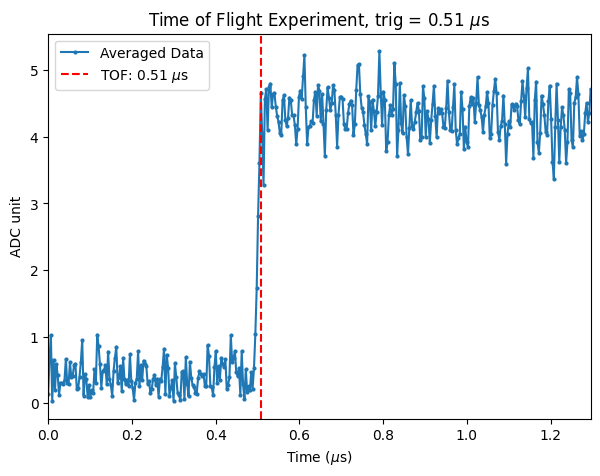

In [ ]:
from qick_workspace.scrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        "res_freq_ge": 6000,
        "ro_length": 1.3,
        "res_legnth": 0.2,
        "res_gain_ge": 1,
        "res_ch": 0,
    }
)

tof = TOF(soc, soccfg, run_cfg)
tof.run(100, liveplot=True)
# tof.plot()


# tof.saveLabber(qubit)

In [3]:
config_all.update("trig_time", 0.49, q_index=qubit)


# YOKO setting

In [5]:
from qick_workspace.tools.YOKOGS200 import YOKOGS200
import pyvisa

rm = pyvisa.ResourceManager()
yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
yoko = YOKOGS200(yoko_connect, rm)

yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [55]:
yoko.SetMode("current")
yokocurrent = 1 * 1e-3
yoko.SetCurrent(yokocurrent)
yoko.GetValue()

Setting Current:   0%|          | 0/1 [00:00<?, ?it/s]

{'unit': 'A', 'value': 0.001}

## Voltage mode

In [5]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# # yoko.GetVoltage()
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE state

## Resonator OneTone

c:\Users\cluster\Desktop\SQC_soc-main\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.7193),
 'Qi': 97077,
 'Ql': 996,
 'absQc': 1007,
 'κ(MHz)': np.float64(6.75)}


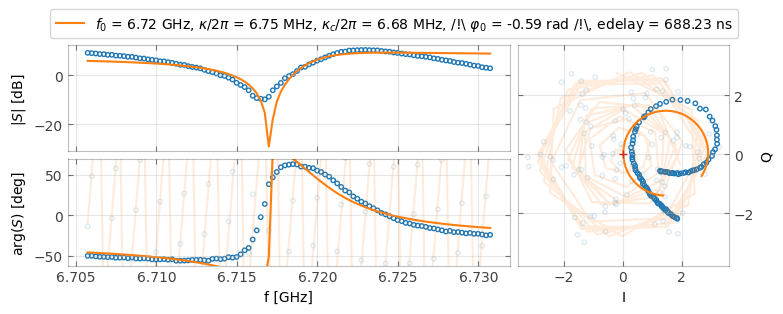

In [20]:
from qick_workspace.scrip.s002_res_spec_ge import Resonator_onetone


START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 15  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101


config_all.update("res.res_gain_ge", 0.4, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = Resonator_onetone(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=10, liveplot=True, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", 6720.7355, q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=yoko_value)


## OneTone PunchOut

In [48]:
from qick_workspace.scrip.s002b_res_punchout_ge import (
    SingleToneSpectroscopyPunchout,
)


START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 7  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 7  # [MHz]
STEPS_freq = 101

START_gain = 0.01  # [MHz]
STOP_gain = 1  # [MHz]
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
    ]
)
punchout = SingleToneSpectroscopyPunchout(soc, soccfg, run_cfg)
punchout.run(py_avg=50, liveplot=True)
# punchout.saveLabber(qubit)

Experiment interrupted at 25 averages. Circle fit is based on partial data.


## Onetone Flux

KeyboardInterrupt: Interrupted at Yoko step: 67


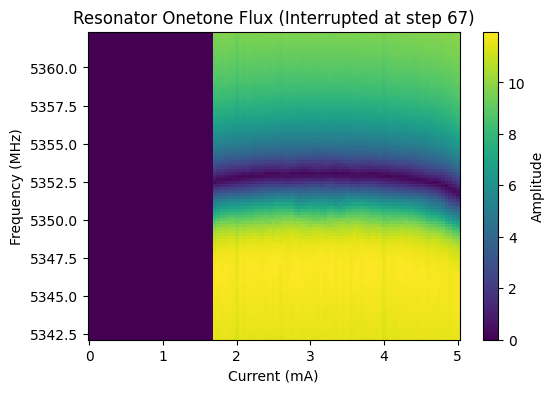

Yoko sweep interrupted at step 67. Data stored.


2026-02-07 01:10:25,714 - SR_Network:BlockingClient - Error: Socket operation timed out


Data save to C:\Users\QEL\Desktop\2DQ12round3\2026\02\Data_0207\s002_onetone_flux_QQ1_009


In [11]:
from qick_workspace.scrip.s002c_res_spec_ge_flux import (
    Resonator_onetone_flux,
)


START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]

STEPS = 101

Start_flux = 5
Stop_flux = 0
Steps_flux = 101
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux) * 1e-3

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("res_gain_ge", 0.2),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
    ]
)

onetone_flux = Resonator_onetone_flux(soc, soccfg, run_cfg)
onetone_flux.run(
    5, liveplot=True, yoko_inst=yoko_connect, yoko_value=yoko_range, mode="current"
)
onetone_flux.saveLabber(qubit, yoko_range, mode="current")

In [40]:
yoko.SetCurrent(-1e-3)

Setting Current:   0%|          | 0/1040 [00:00<?, ?it/s]

## Hardware loop

In [115]:
# from single_qubit_pyscrip_v1_1.s002c_res_spec_ge_flux import Resonator_onetone_flux

# run_cfg = select_config_idx(config, qubit_idx)

# START_FREQ = 5000
# STOP_FREQ = 6000
# STEPS = 101
# yoko_range = np.linspace(0, 1, 21)*1e-3
# run_cfg.update([('steps', STEPS),
#                 ('steps_flux', 21),
#                 ('flux_ch', 2),
#                 ('flux_length', 10),
#                 ('saturate_times', 0.5),
#                 ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
#                 ('flux_gain', QickSweep1D('fluxloop', -0.01, 0.01)),
#                 ('relax_delay', 1)
#                 ])

# onetone_flux = Resonator_onetone_flux(soc, soccfg, run_cfg)
# onetone_flux.liveplot_hardwre(50)

## Cooling sweep

In [28]:
# from single_qubit_pyscrip_v1_2.s002d_res_cooling_ge import SingleToneSpectroscopyCooling

# run_cfg = select_config_idx(config, qubit_idx)
# SPAN1 = 20
# cooling_freq = {}
# cooling_freq["f12"] = 6.303
# cooling_freq["f0g1"] = 1.290
# START_FREQ_1 = round(cooling_freq["f12"] * 1e3, 3) - SPAN1  # [MHz]
# STOP_FREQ_1 = round(cooling_freq["f12"] * 1e3, 3) + SPAN1  # [MHz]
# STEPS_freq_1 = 31

# SPAN2 = 20
# START_FREQ_2 = round(cooling_freq["f0g1"] * 1e3, 3) - SPAN2  # [MHz]
# STOP_FREQ_2 = round(cooling_freq["f0g1"] * 1e3, 3) + SPAN2  # [MHz]
# STEPS_freq_2 = 31

# config.update(
#     [
#         ("cool_ch1", 5),
#         ("cool_gain_1", 0.5),
#         ("nqz_cool_ch1", 2),
#         ("cool_mixer1", round(cooling_freq["f12"] * 1e3, 3)),
#         ("cool_ch2", 7),
#         ("cool_gain_2", 0.5),
#         ("nqz_cool_ch2", 2),
#         ("cool_mixer2", round(cooling_freq["f0g1"] * 1e3, 3)),
#         ("cool_length", 2),
#     ]
# )

# run_cfg.update(
#     [
#         ("f_steps1", STEPS_freq_1),
#         ("cool_freq_1", QickSweep1D("freqloop1", START_FREQ_1, STOP_FREQ_1)),
#         ("f_steps2", STEPS_freq_2),
#         ("cool_freq_2", QickSweep1D("freqloop2", START_FREQ_2, STOP_FREQ_2)),
#     ]
# )
# cooling = SingleToneSpectroscopyCooling(soc, soccfg, run_cfg)
# cooling.run(py_avg=30, liveplot=True)
# cooling.saveLabber(qubit_idx)

In [29]:
# config.update(
#     [
#         ("cool_ch1", 5),
#         ("cool_freq_1", 6309),
#         ("cool_gain_1", 0.5),
#         ("nqz_cool_ch1", 2),
#         ("cool_mixer1", 6309),
#         ("cool_ch2", 7),
#         ("cool_freq_2", 1278),
#         ("cool_gain_2", 0.5),
#         ("nqz_cool_ch2", 2),
#         ("cool_mixer2", 1278),
#         ("cool_length", 3),
#     ]
# )


## Qubit Spectrum ge

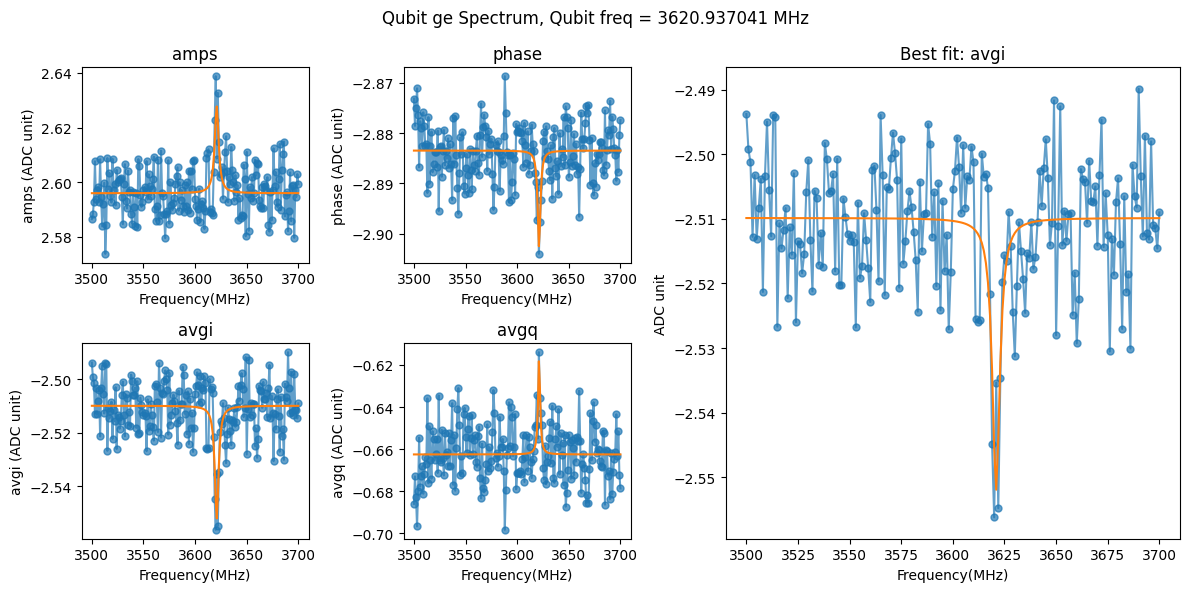

In [23]:
from qick_workspace.scrip.s003_qubit_spec_ge import Qubit_Twotone

center = 3600
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]

STEPS = 201

# config_all.update("ch.qb_ch", 0, q_index=qubit)
# config_all.update("res.res_gain_ge", 0.3, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qmixer_freq", center),
        ("qbgain_ge", 0.2),
        ("qb_length_ge", 5),
        ("relax_delay", 2),
        ("nqz_qb", 1),
    ]
)

spectrum_ge = Qubit_Twotone(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(50, liveplot=True)
config_all.update("qb.qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb.qb_mixer", f_ge, q_index=qubit)

# spectrum_ge.saveLabber(qubit, yoko_value=yoko_value)

### save

In [24]:
# import json

# FILENAME = "qubit_auto_test.json"
# # freq_report = {}


# def write_json_report(data_to_save):
#     output_data = {
#         "unit": {"current": "A", "frequency": "MHz"},
#         "qubit_freq_vs_current": data_to_save,
#     }

#     with open(FILENAME, "w") as f:
#         json.dump(output_data, f, indent=4)


# if os.path.exists(FILENAME):
#     try:
#         with open(FILENAME, "r") as f:
#             existing_data = json.load(f)
#             freq_report = existing_data.get("qubit_freq_vs_current", {})
#         print(f"Loaded existing data from {FILENAME}. Resuming sweep.")
#     except json.JSONDecodeEror:
#         print(f"Error reading existing JSON file. Starting new report.")

# print(f"--- Starting Qubit Two-tone Sweep, saving to {FILENAME} ---")
# yoko_value = yoko.GetValue()
# current_key = f"{yoko_value['value']:.4f} A"
# freq_report[current_key] = round(f_ge, 6)

# print(f"Current: {current_key}, Qubit Freq: {f_ge:.6f} MHz")

# write_json_report(freq_report)

## Qubit Spectrum ge Flux

In [46]:
from qick_workspace.scrip.s003a_qubit_flux_spec_ge import (
    Qubit_Twotone_Flux,
)

### qubit frequency scan range ###
center = 2500
SPAN = 1000
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 501
### qubit flux scan range ###
Start_flux = -4e-3
Stop_flux = -5e-3
Steps_flux = 21
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux)


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.5),
        ("qb_length_ge", 5.0),
        ("relax_delay", 1),
        ("cooling", False),
        ("qb_ch", 2),
    ]
)

spectrum_ge_flux = Qubit_Twotone_Flux(soc, soccfg, run_cfg)
spectrum_ge_flux.run(
    10, liveplot=True, yoko_inst=yoko_connect, yoko_value=yoko_range, mode="current"
)
spectrum_ge_flux.saveLabber(qubit, yoko_range, mode="current")

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_31648\2270328576.py", line 34, in <module>
    10, liveplot=True, yoko_inst=yoko_connect, yoko_value=yoko_range, mode="current"
NameError: name 'yoko_connect' is not defined


## Length Rabi ge

In [47]:
from qick.asm_v2 import AveragerProgramV2
class LengthRabiProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg["ro_ch"]
        res_ch = cfg["res_ch"]
        qb_ch = cfg["qb_ch"]

        self.declare_gen(ch=res_ch, nqz=cfg["nqz_res"])

        if self.soccfg["gens"][qb_ch]["type"] == "axis_sg_int4_v2":
            self.declare_gen(ch=qb_ch, nqz=cfg["nqz_qb"], mixer_freq=cfg["qb_mixer"])
        else:
            self.declare_gen(ch=qb_ch, nqz=cfg["nqz_qb"])

        self.declare_readout(ch=ro_ch, length=cfg["ro_length"])
        self.add_readoutconfig(
            ch=ro_ch, name="myro", freq=cfg["res_freq_ge"], gen_ch=res_ch
        )
        
        self.add_gauss(
            ch=res_ch,
            name="readout",
            sigma=cfg["res_sigma"],
            length=5 * cfg["res_sigma"],
            even_length=True,
        )
        self.add_pulse(
            ch=res_ch,
            name="res_pulse",
            ro_ch=ro_ch,
            style="flat_top",
            envelope="readout",
            length=cfg["res_length"],
            freq=cfg["res_freq_ge"],
            phase=cfg["res_phase"],
            gain=cfg["res_gain_ge"],
        )
        self.add_loop('lenloop', cfg['steps'])
        self.add_gauss(
            ch=qb_ch,
            name="qb",
            sigma=cfg["sigma_ge"],
            length=5 * cfg["sigma_ge"],
            even_length=True,
        )
        self.add_pulse(
            ch=qb_ch,
            name="qb_pulse",
            style="flat_top",
            envelope="qb",
            length=cfg["qb_length_ge"],
            freq=cfg["qb_freq_ge"],
            phase=0,
            gain=cfg["qb_gain_ge"],
        )


    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg["ro_ch"], name="myro", t=0)
        self.pulse(ch=cfg["qb_ch"], name="qb_pulse", t=0)  # play probe pulse

        self.delay_auto(t=0.05, tag="waiting")

        self.pulse(ch=cfg["res_ch"], name="res_pulse", t=0)
        self.trigger(ros=[cfg["ro_ch"]], pins=[0], t=cfg["trig_time"])


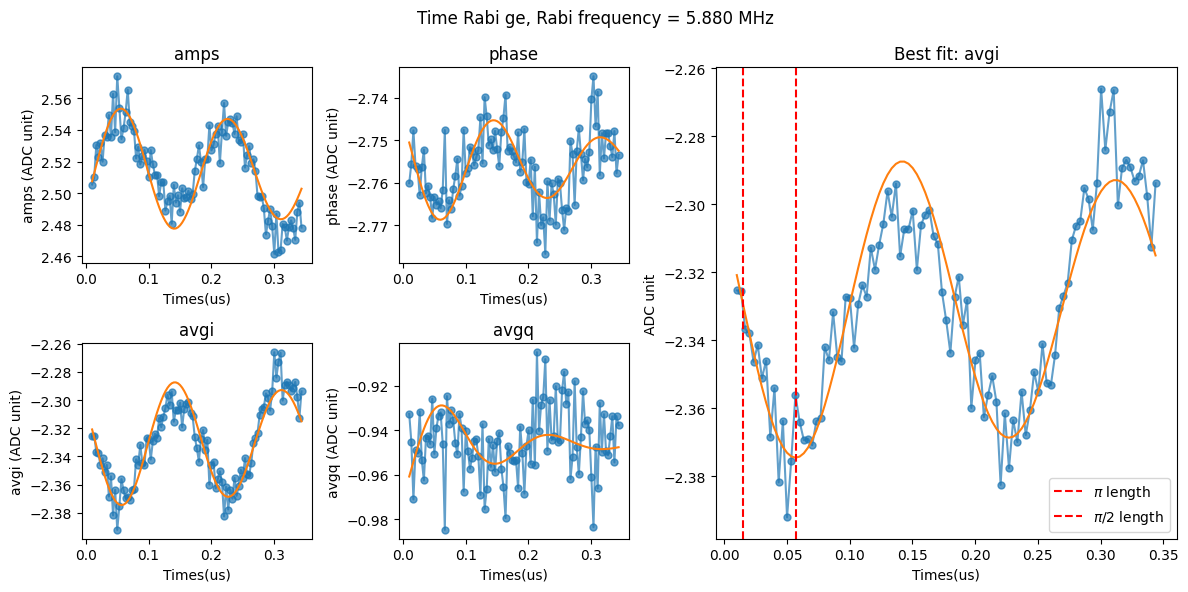

In [55]:
# from qick_workspace.scrip.s004_time_rabi_ge import Time_Rabi
from qick_workspace.scrip.s004_time_rabi_ge2 import Time_Rabi

time_array = np.linspace(0.01, 0.2, 101)


config_all.update("qb.sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 30, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.2),
        ("qb_length_ge", QickSweep1D("lenloop", 0.01,0.5)),
        ("steps", 101)
    ]
)

Trabi = Time_Rabi(soc, soccfg, run_cfg)
a, b = Trabi.run(50, liveplot=True, time_axis=time_array)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

# prog = LengthRabiProgram(
#                 soccfg,
#                 reps=100,
#                 final_delay=50,
#                 cfg=run_cfg,
#             )
# prog.get_pulse_param("qb_pulse", "length", as_array=True)
# iq_list = prog.acquire(soc, rounds=50, progress=True)
# iqdata = iq_list[0][0].dot([1, 1j])

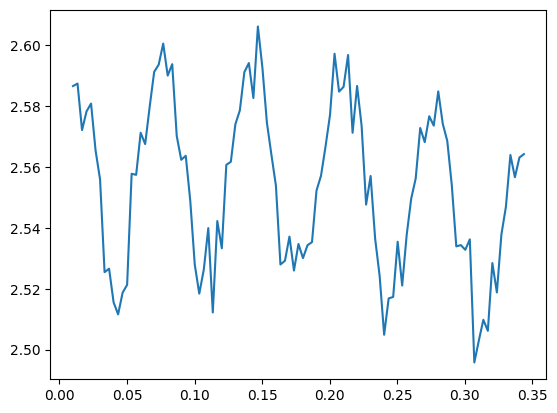

In [52]:
time_array = prog.get_pulse_param("qb_pulse", "length", as_array=True)
plt.plot(time_array, np.abs(iqdata))

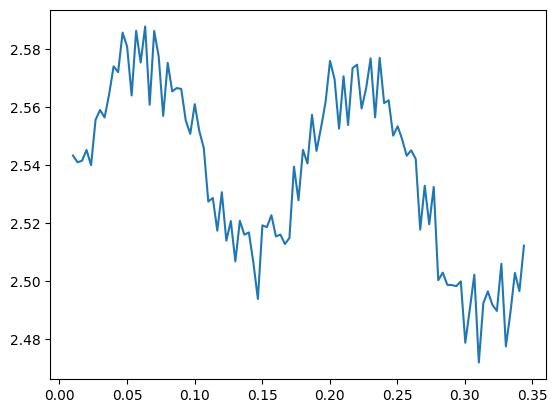

In [54]:
time_array = prog.get_pulse_param("qb_pulse", "length", as_array=True)
plt.plot(time_array, np.abs(iqdata))

## Power Rabi ge

Experiment interrupted at 16 averages. Fit is based on partial data.


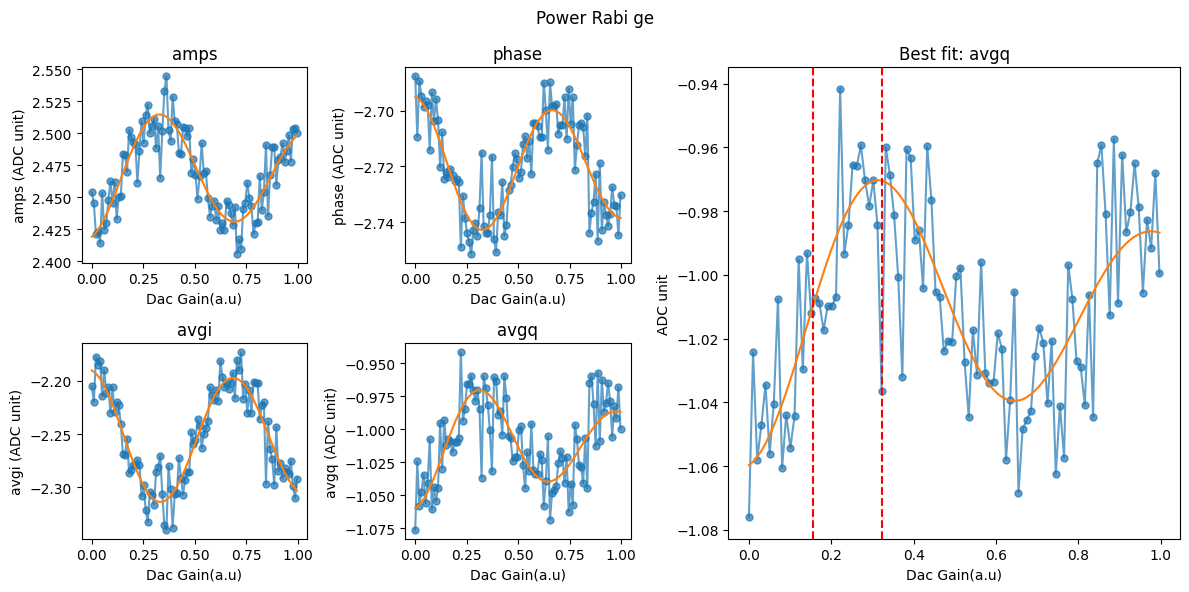

In [25]:
from qick_workspace.scrip.s005_power_rabi_ge import Amp_Rabi


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ge", 0.02, q_index=qubit)
config_all.update("qb.nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("cooling", False),
    ]
)

prabi = Amp_Rabi(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi.run(100, liveplot=True)
config_all.update("qb.pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("qb.pi2_gain_ge", pi2_gain, q_index=qubit)
# prabi.saveLabber(qubit, yoko_value=yoko_value)

## Amplified Amplitude Error(AAE)

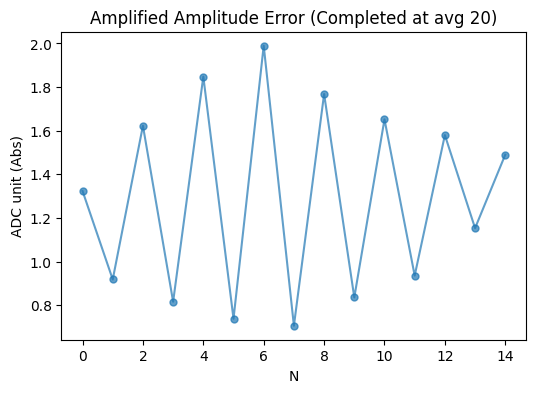

In [ ]:
from qick_workspace.scrip.s005a_AAE import AAE


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("AAE", "pi2"),
        ("pi2_gain_ge", 0.43164),
    ]
)


aae = AAE(soc, soccfg, run_cfg)
aae.run(20, liveplot=True, iteration=15)


## Ramsey

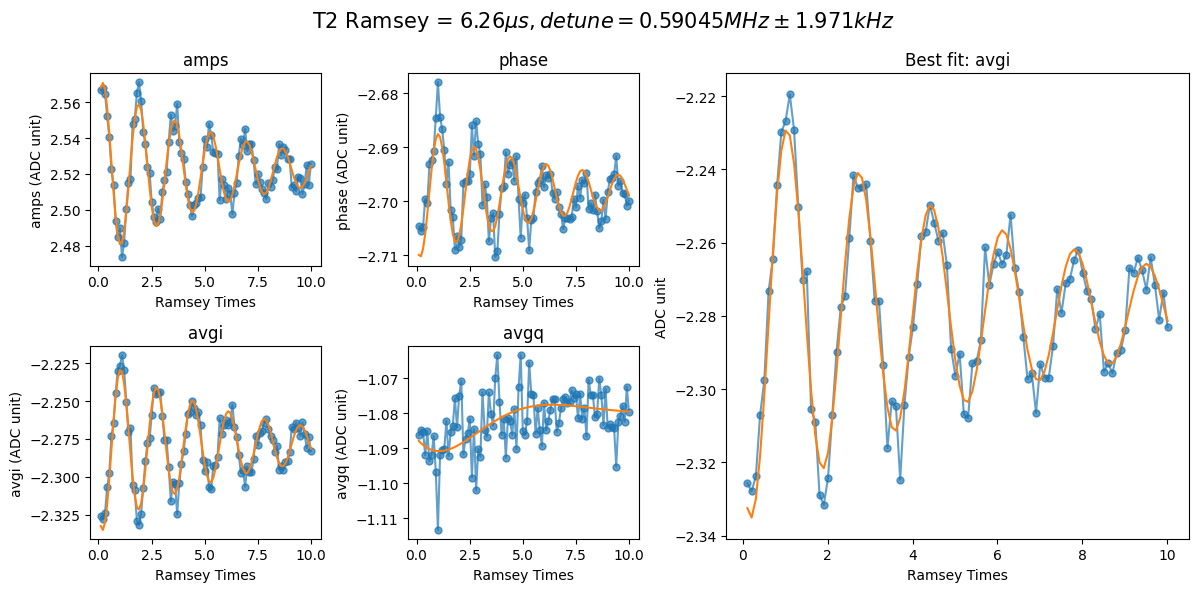

In [29]:
from qick_workspace.scrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 1),
    ]
)

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(100, liveplot=True)
# t2r.saveLabber(qubit_idx, yoko_value=yoko_value)


In [37]:
t2r.saveLabber("Q1", yoko_value=None)

Data save to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0304\s006_Ramsey_ge_QQ1_001


In [27]:
config_all.update("qb.qb_freq_ge", t2r.correct_detune(), qubit)

over detune 0.57598MHz


## Echo

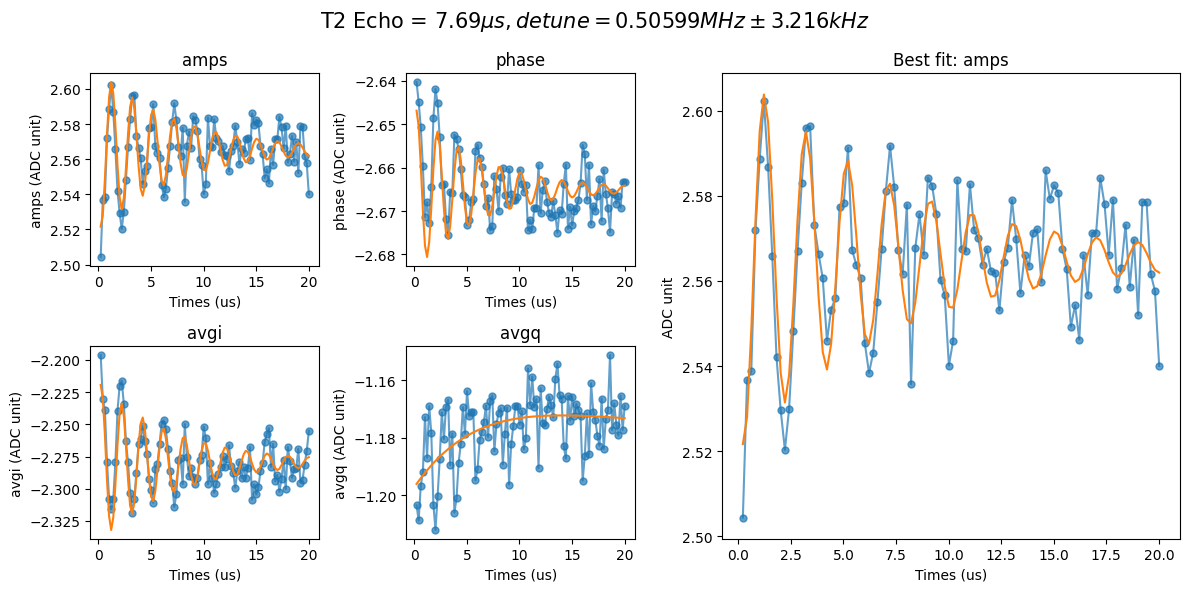

In [ ]:
from qick_workspace.scrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 20  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.5),
        ("cooling", False),
    ]
)

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(50, liveplot=True)

t2e.saveLabber(qubit_idx, yoko_value=yoko_value)

In [39]:
t2e.saveLabber("Q1", yoko_value=None)


Data save to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0304\s007_SpinEcho_ge_Q1_002


## T1

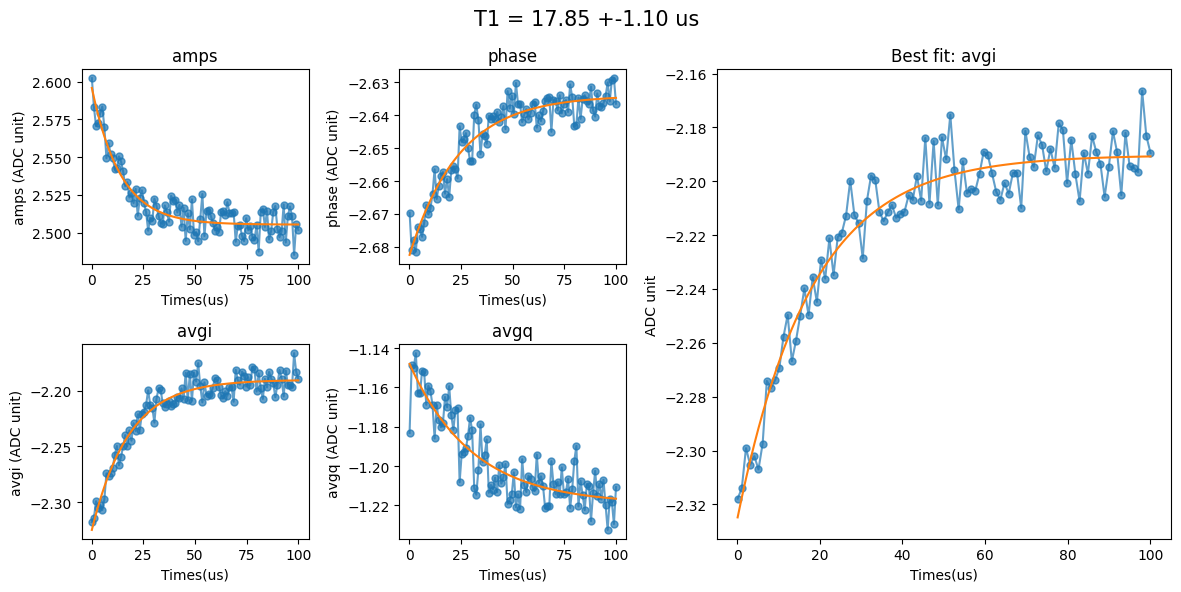

In [35]:
from qick_workspace.scrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 50),
        ("cooling", False),
    ]
)

t1 = T1(soc, soccfg, run_cfg)
t1.run(50, liveplot=True)
# t1.saveLabber(qubit, yoko_value=yoko_value)

In [36]:
t1.saveLabber(qubit, yoko_value=None)

Data save to D:\Labber_Data\Jay\purcell_tmon\2026\03\Data_0304\s008_T1_ge_Q1_002


## Single shot

  0%|          | 0/5000 [00:00<?, ?it/s]

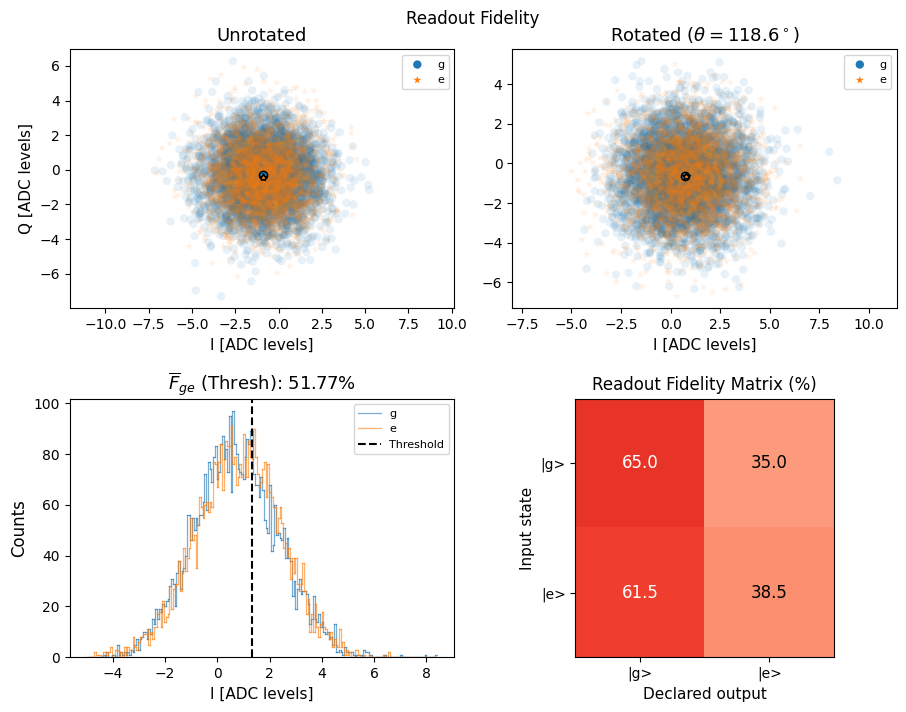

Theta: 118.62 deg
Fidelity: 51.774%
Fidelity Matrix (%):
 [[65.04       34.96      ]
 [61.49229846 38.50770154]]


{'fidelity': np.float64(0.5177385077015402),
 'thresholds': [np.float64(1.3070654046991503)],
 'angle': np.float64(118.62379440539935),
 'confusion_matrix': array([[65.04      , 34.96      ],
        [61.49229846, 38.50770154]]),
 'data': {'Ig': array([-1.72357724, -3.21138211, -2.4796748 , ...,  0.65853659,
          0.84552846, -2.26829268]),
  'Qg': array([-1.76422764,  0.7804878 , -1.44715447, ...,  1.5203252 ,
          0.3495935 ,  2.1300813 ]),
  'Ie': array([-1.88617886, -0.7804878 , -1.68292683, ..., -1.72357724,
          0.59349593, -0.06504065]),
  'Qe': array([ 0.53658537,  0.11382114,  0.21138211, ...,  1.7804878 ,
          0.56097561, -2.83739837])},
 'fids_list': [np.float64(0.5177385077015402)]}

In [41]:
from qick_workspace.scrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 0.4
run_cfg["res_gain_ge"] = 0.17341
# run_cfg["res_freq_ge"] = 5352.28064
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh.plot(fid_avg=True, verbose=True, fit=False)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

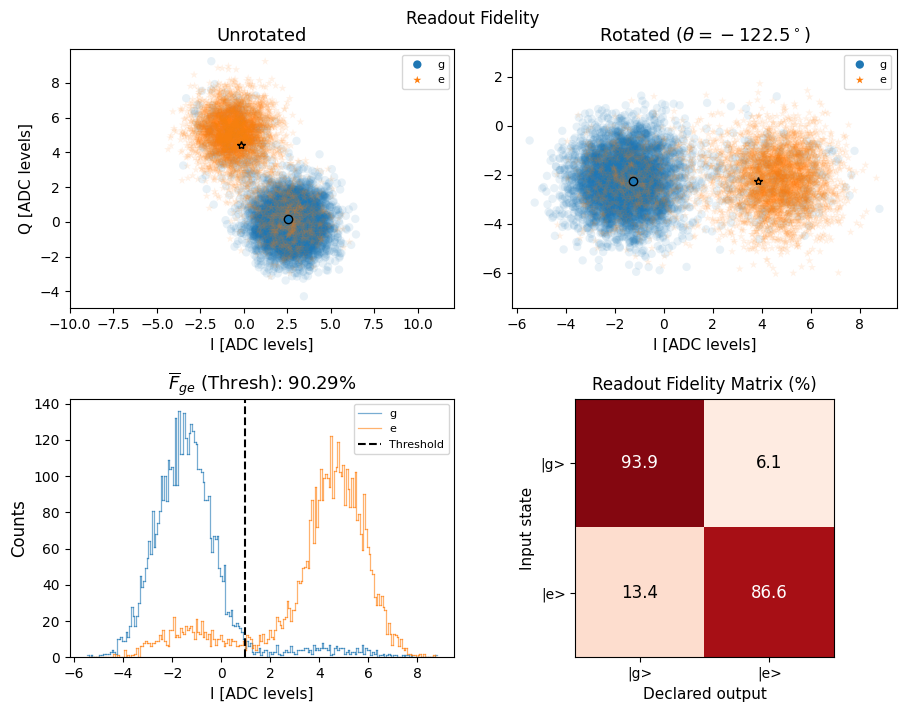

Theta: -122.55 deg
Fidelity: 90.290%
Fidelity Matrix (%):
 [[93.94  6.06]
 [13.36 86.64]]


{'fidelity': np.float64(0.9029),
 'thresholds': [np.float64(0.9502657561361385)],
 'angle': np.float64(-122.54958847371272),
 'confusion_matrix': array([[93.94,  6.06],
        [13.36, 86.64]]),
 'data': {'Ig': array([2.43902439, 3.78861789, 2.95934959, ..., 2.99186992, 3.70731707,
         2.38211382]),
  'Qg': array([ 1.97560976,  0.68292683, -0.71544715, ..., -0.39837398,
          1.30081301,  1.04878049]),
  'Ie': array([ 1.49593496, -0.79674797,  0.11382114, ...,  0.75609756,
          0.39837398, -0.34146341]),
  'Qe': array([5.7398374 , 5.51219512, 3.91869919, ..., 2.57723577, 5.29268293,
         2.57723577])},
 'fids_list': [np.float64(0.9029)]}

In [ ]:
from qick_workspace.scrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 0.4
run_cfg["res_gain_ge"] = 0.17341
run_cfg["res_freq_ge"] = 5352.28064
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
iqlst = ssh.run(SHOT, shot_f=False)
ssh.plot(fid_avg=True, verbose=True, fit=False)


### Single Shot optimize

In [43]:
from qick_workspace.scrip.s000_SingleShot_ge_prog_opt import (
    SingleShot_ge_opt,
)

run_cfg = config_all.get_qubit(qubit)
SHOT = 4000


freq_axis = np.linspace(run_cfg["res_freq_ge"] - 1, run_cfg["res_freq_ge"] + 1, 6)
gain_axis = np.linspace(0.15, 0.9, 9)
length_axis = np.linspace(0.1, 2, 9)
sweep_para = {"freq": run_cfg["res_freq_ge"], "gain": gain_axis, "length": length_axis}


ssh = SingleShot_ge_opt(soc, soccfg, run_cfg)
ssh.run(SHOT, sweep_para)
ssh.analyze()

Length loop:   0%|          | 0/9 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/9 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/9 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/9 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/9 [00:00<?, ?it/s]

...

Gain loop:   0%|          | 0/9 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/9 [00:00<?, ?it/s]

Analyze max fidelity:   0%|          | 0/9 [00:00<?, ?it/s]


--- Grid Search Result ---
Max fidelity (on grid): 0.5507
At length=2.000 us, gain=0.80625 DAC, freq=6720.73550 MHz

--- Interpolated Result ---
Max fidelity (interpolated): 0.5512
At length=2.000 us, gain=0.78873 DAC, freq=6720.73550 MHz


(np.float64(2.0), np.float64(0.78873), 6720.7355)

# EF state (Not repaired yet)

## Cooling to e

In [ ]:
from single_qubit_pyscrip_v1_1.s002d_res_cooling_ge import SingleToneSpectroscopyCooling

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ_1 = 3150  # [MHz]
STOP_FREQ_1 = 3300  # [MHz]
STEPS_freq_1 = 51

START_FREQ_2 = 1900  # [MHz]
STOP_FREQ_2 = 2050  # [MHz]
STEPS_freq_2 = 51

config.update(
    [
        ("cool_ch1", 5),
        ("cool_gain_1", 0.8),
        ("nqz_cool_ch1", 2),
        ("cool_mixer1", 3000),
        ("cool_ch2", 2),
        ("cool_gain_2", 0.4),
        ("nqz_cool_ch2", 2),
        ("cool_mixer2", 2000),
        ("cool_length", 1),
    ]
)

run_cfg.update(
    [
        ("f_steps1", STEPS_freq_1),
        ("cool_freq_1", QickSweep1D("freqloop1", START_FREQ_1, STOP_FREQ_1)),
        ("f_steps2", STEPS_freq_2),
        ("cool_freq_2", QickSweep1D("freqloop2", START_FREQ_2, STOP_FREQ_2)),
    ]
)
cooling = SingleToneSpectroscopyCooling(soc, soccfg, run_cfg)
cooling.run(py_avg=20, liveplot=True)
# cooling.saveLabber(qubit_idx)

KeyboardInterrupt: 

## Onetone EF

c:\Users\QEL\Desktop\SQC_soc\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(5.3519),
 'Qi': 67647,
 'Ql': 1176,
 'absQc': 1197,
 'κ(MHz)': np.float64(4.55)}


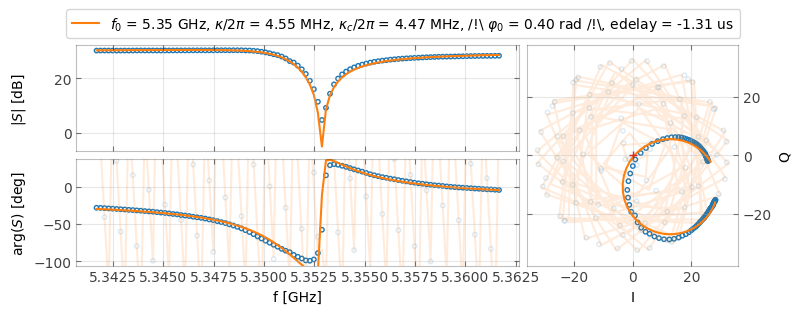

In [15]:
from qick_workspace.scrip.s009_res_spec_ef import Resonator_onetone_ef


START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101


config_all.update("res.res_gain_ge", 0.2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 1),
    ]
)

onetone = Resonator_onetone_ef(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=20, liveplot=True, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=yoko_value)


## Qubit Spectrum ef

In [157]:
yoko_value = None

Experiment interrupted at 5 averages. Fit is based on partial data.


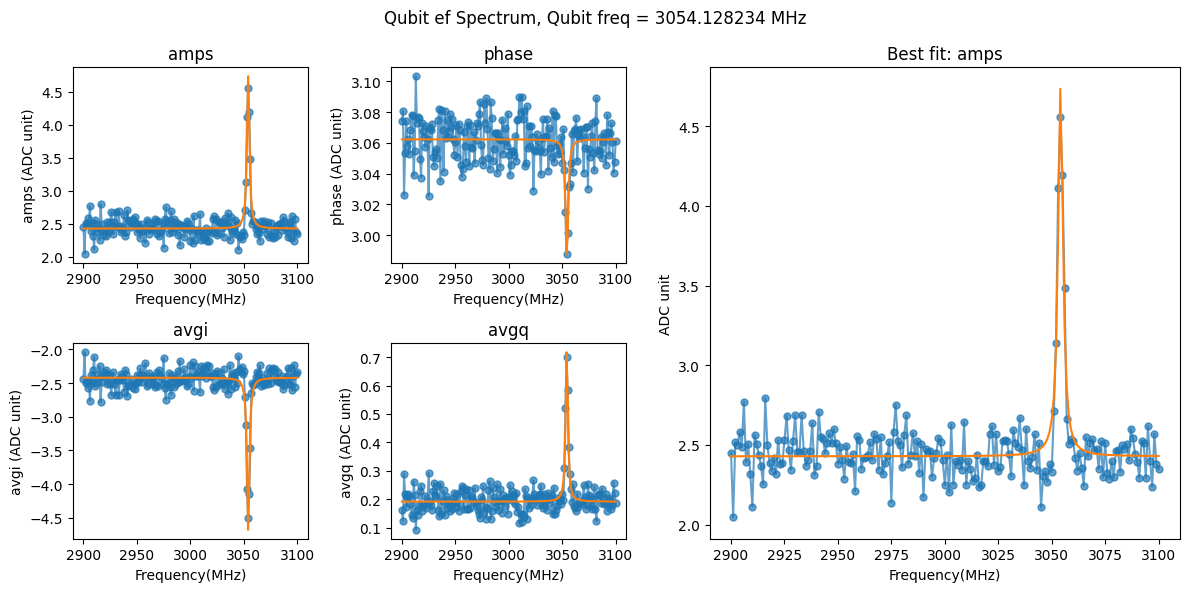

In [13]:
from qick_workspace.scrip.s010_qubit_spec_ef import Qubit_Twotone_ef

center = 3000
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]

STEPS = 201


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.1),
        ("qb_length_ef", 0.5),
        ("relax_delay", 50),
        ("qb_ch_ef", 2),
        ("ro_length", 1),
    ]
)

spectrum_ef = Qubit_Twotone_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ef.run(20, liveplot=True)
config_all.update("qb.qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb.qb_mixer_ef", f_ef, q_index=qubit)

# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

## Rabi EF

2026-02-09 12:01:32,594 - SR_Network:BlockingClient - Error: Socket operation timed out


Data save to C:\Users\QEL\Desktop\2DQ12round3\2026\02\Data_0209\s011_power_rabi_ef_Q1_006


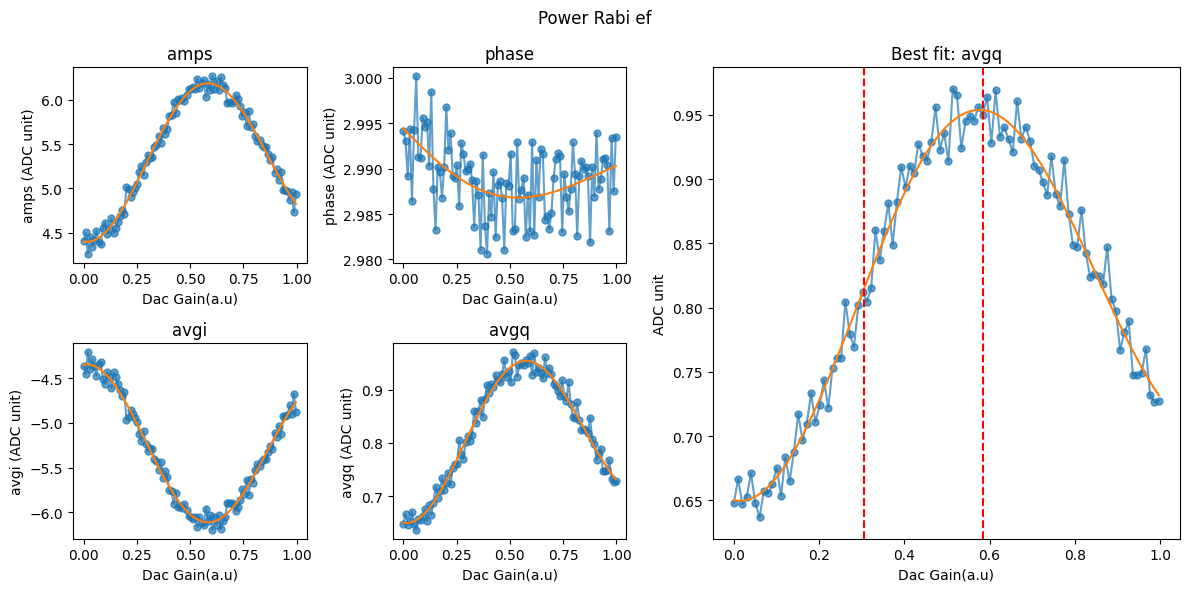

In [15]:
from qick_workspace.scrip.s011_power_rabi_ef import Amp_Rabi_ef


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.02, q_index=qubit)
config_all.update("relax_delay", 30, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
    ]
)

prabi_ef = Amp_Rabi_ef(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi_ef.run(10, liveplot=True)
config_all.update("qb.pi_gain_ef", pi_gain, q_index=qubit)
config_all.update("qb.pi2_gain_ef", pi2_gain, q_index=qubit)
# prabi_ef.saveLabber(qubit, yoko_value=yoko_value)

## Ramsey ef

Experiment interrupted at 6 averages. Fit is based on partial data.


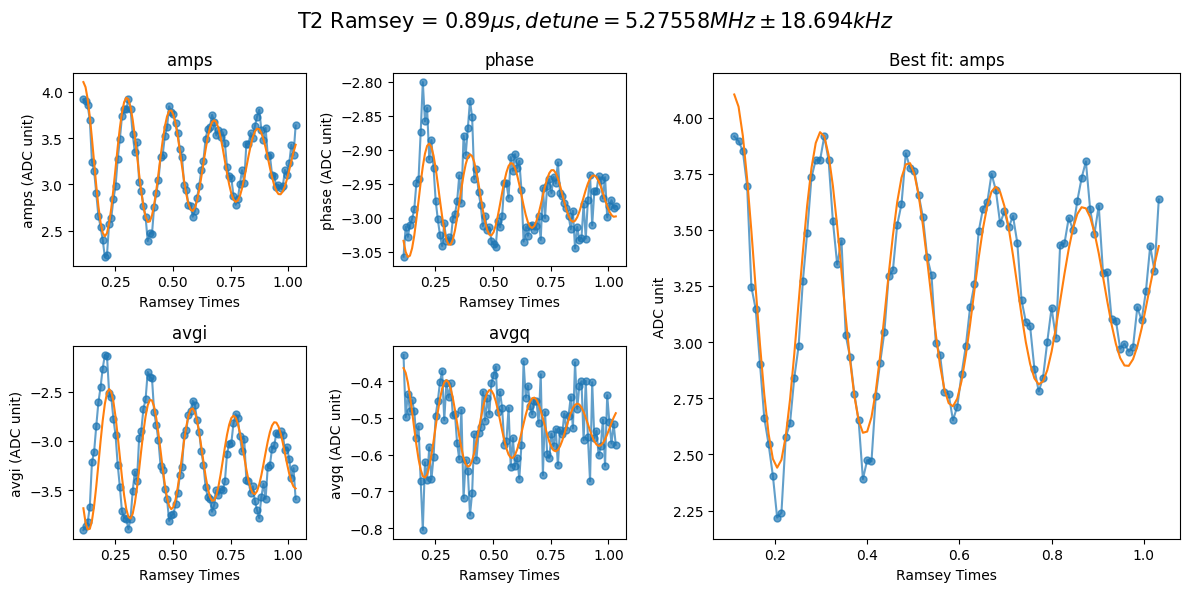

In [16]:
from qick_workspace.scrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 1  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 5),
        ("ro_length", 0.3),
    ]
)

t2r = Ramsey_ef(soc, soccfg, run_cfg)
t2r.run(10, liveplot=True)
# t2r.saveLabber(qubit, yoko_value=None)


In [17]:
config_all.update("qb.qb_freq_ef", t2r.correct_detune(), qubit)

over detune 0.27558MHz


## T1 ef

Data save to C:\Users\QEL\Desktop\2DQ12round3\2025\12\Data_1210\s013_T1_ef_Q1_001


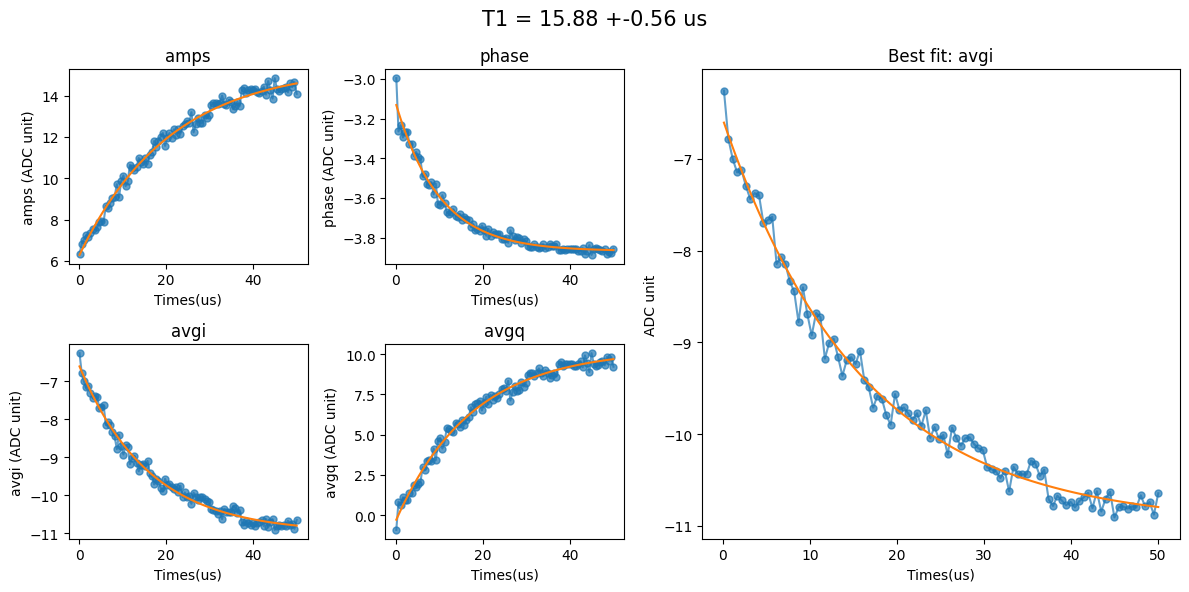

In [97]:
from qick_workspace.scrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 50  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 50),
        ("cooling", False),
    ]
)

t1 = T1_ef(soc, soccfg, run_cfg)
t1.run(50, liveplot=True)
t1.saveLabber(qubit, yoko_value=yoko_value)

## singel shot gef

  0%|          | 0/5000 [00:00<?, ?it/s]

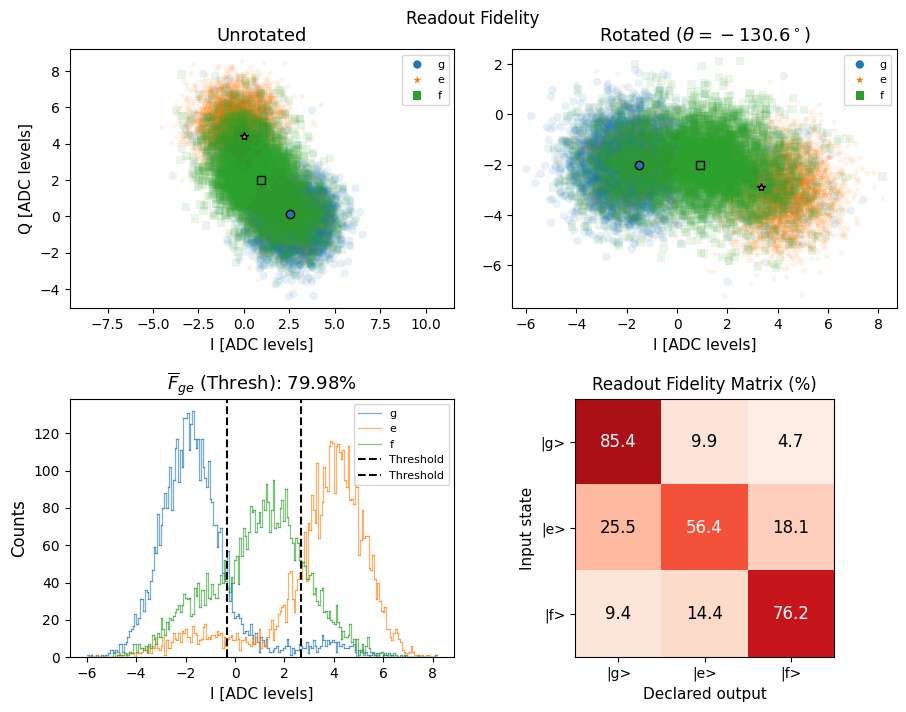

Theta: -130.56 deg
Fidelity: 79.980%
Fidelity Matrix (%):
 [[85.44  9.86  4.7 ]
 [25.48 56.4  18.12]
 [ 9.42 14.38 76.2 ]]


{'fidelity': np.float64(0.7998000000000001),
 'thresholds': [np.float64(-0.3224010083168878),
  np.float64(2.650161957451246)],
 'angle': np.float64(-130.56305092006335),
 'confusion_matrix': array([[85.44,  9.86,  4.7 ],
        [25.48, 56.4 , 18.12],
        [ 9.42, 14.38, 76.2 ]]),
 'data': {'Ig': array([ 2.33333333,  4.08943089,  3.30894309, ..., -1.39837398,
          2.12195122,  3.        ]),
  'Qg': array([-1.22764228,  0.32520325,  0.72357724, ...,  3.4796748 ,
         -0.04065041, -1.49593496]),
  'Ie': array([ 1.60162602,  0.97560976, -0.69105691, ...,  0.09756098,
         -0.3495935 ,  0.25203252]),
  'Qe': array([3.        , 1.62601626, 5.6097561 , ..., 4.54471545, 1.5203252 ,
         0.68292683]),
  'If': array([ 0.83739837, -0.80487805,  0.22764228, ...,  3.91056911,
          1.17073171,  0.11382114]),
  'Qf': array([3.8699187 , 6.64227642, 5.19512195, ..., 1.16260163, 6.30894309,
         4.47154472])},
 'fids_list': [np.float64(0.7998000000000001)]}

In [23]:
from qick_workspace.scrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)

run_cfg["ro_length"] = 0.4
run_cfg["res_gain_ge"] = 0.17341
run_cfg["res_freq_ge"] = 5352.28064
SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True, fit=False)

# ALLXY

  0%|          | 0/21 [00:00<?, ?it/s]

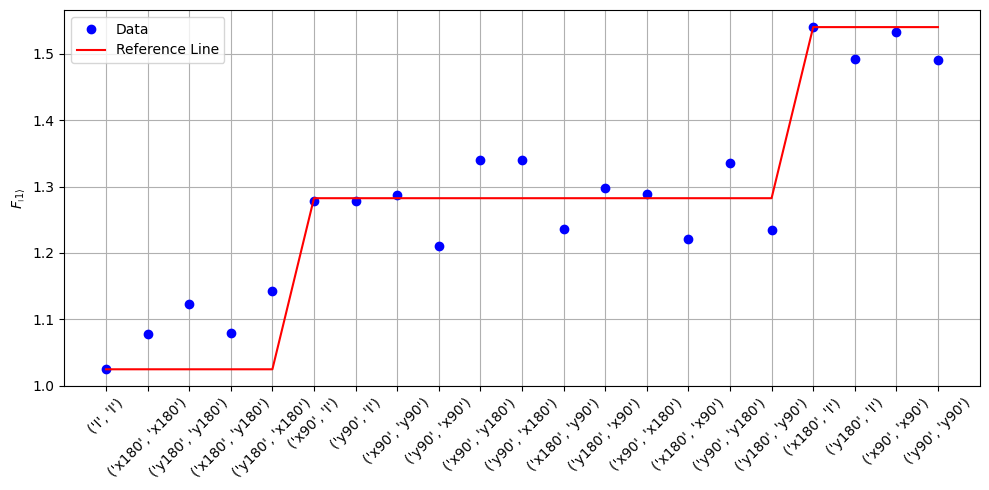

In [ ]:
from qick_workspace.scrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)

allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(10)
allxy.plot()

# State Tomography

Calibrating |0> state...
Calibrating |1> state...
IQ Ground (|0>): (0.4754134114583334+0.8862805989583332j)
IQ Excited (|1>): (0.8103131510416667+1.190084635416667j)
Running tomography for state prepared by: x180


Tomography (State: x180):   0%|          | 0/3 [00:00<?, ?it/s]

Raw Tomography IQ data: {'X': np.complex128(0.6913346354166666+1.1142539062499999j), 'Y': np.complex128(0.6610774739583333+1.0636119791666665j), 'Z': np.complex128(0.77211328125+1.184587890625j)}

Measured Expectation Values:
  <X> = -0.3849
  <Y> = -0.1352
  <Z> = -0.8585

--- Raw Density Matrix (before MLE) ---
[[ 0.07073967+0.j         -0.19243286+0.06762119j]
 [-0.19243286-0.06762119j  0.92926033+0.j        ]]

--- Final MLE Reconstructed Density Matrix ---
[[ 0.07073967+0.00000000e+00j -0.19243286+6.76211860e-02j]
 [-0.19243286-6.76211860e-02j  0.92926033+5.55111512e-17j]]

Purity: 0.95173 (1.0 = pure state)


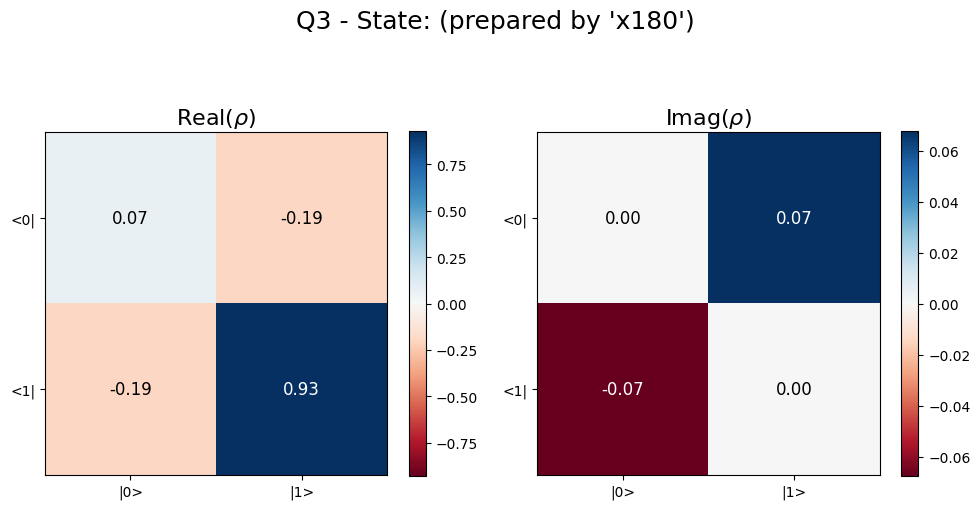

c:\Users\QEL\Desktop\SQC_soc_v2\qick_workspace\scrip\s016_state_tomography.py:509: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


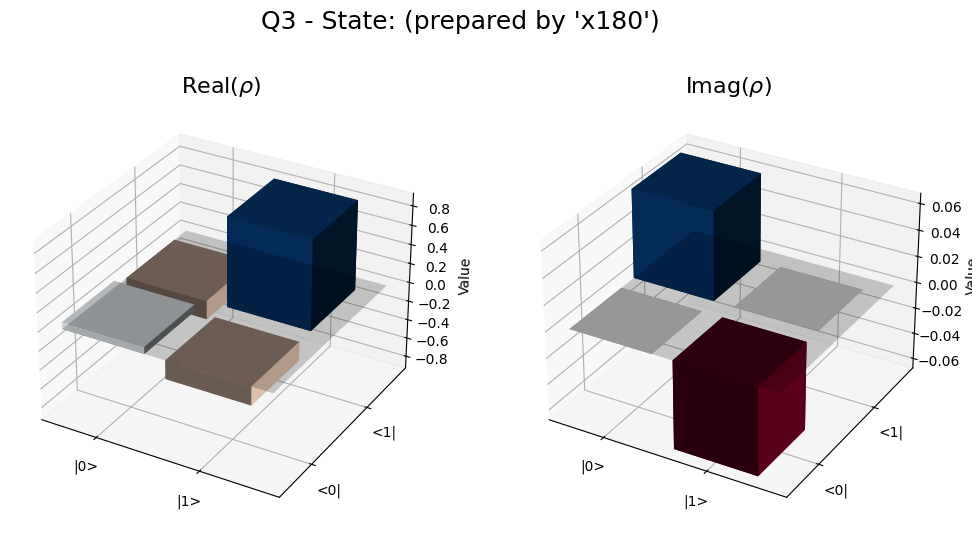

(<Figure size 1200x600 with 2 Axes>,
 (<Axes3D: title={'center': 'Real($\\rho$)'}, zlabel='Value'>,
  <Axes3D: title={'center': 'Imag($\\rho$)'}, zlabel='Value'>))

In [57]:
from qick_workspace.scrip.s016_state_tomography import Tomography

pyavg = 10


run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(soc, soccfg, run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x180")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking

In [58]:
from qick_workspace.scrip.s015_Single_qubit_RB import (
    RandomizedBenchmarking,
)

run_cfg = config_all.get_qubit(qubit)


py_avg = 1
max_circuit_depth = 100
delta_clifford = 5
number_sample = 10


all_rb_results = []


print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)


--- Running Standard RB (Ref) ---


Standard RB depth:   0%|          | 0/20 [00:00<?, ?it/s]

Number of samples:   0%|          | 0/10 [00:00<?, ?it/s]

Number of samples:   0%|          | 0/10 [00:00<?, ?it/s]

Number of samples:   0%|          | 0/10 [00:00<?, ?it/s]

Number of samples:   0%|          | 0/10 [00:00<?, ?it/s]

Number of samples:   0%|          | 0/10 [00:00<?, ?it/s]

Number of samples:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Interleve RB

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)